# Machine Learning on Customer Behaviour

First, let's import the libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Let's read the given csv files

In [5]:
train_data=pd.read_csv('customer_behavior_train.csv')
test_data=pd.read_csv('customer_behavior_test.csv')

In [6]:
train_data.head()

,Time_on_site,Pages_viewed,Clicked_ad,Cart_value,Referral,Browser_Refresh_Rate,Last_Ad_Seen,Purchase
0,2.29,5.37,1,10.00,Facebook,143.14,D,1
1,7.49,16.36,0,25.52,Instagram,136.66,A,1
2,5.71,13.69,0,10.00,Google,67.13,C,0
3,1.23,3.22,1,41.49,Google,92.12,C,0
4,3.55,10.72,0,21.57,Direct,70.31,B,0


In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Time_on_site          1800 non-null   float64
 1   Pages_viewed          1800 non-null   float64
 2   Clicked_ad            1800 non-null   int64  
 3   Cart_value            1800 non-null   float64
 4   Referral              1800 non-null   object 
 5   Browser_Refresh_Rate  1800 non-null   float64
 6   Last_Ad_Seen          1800 non-null   object 
 7   Purchase              1800 non-null   int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 112.6+ KB


## EDA

To view everything, let's call pairplot

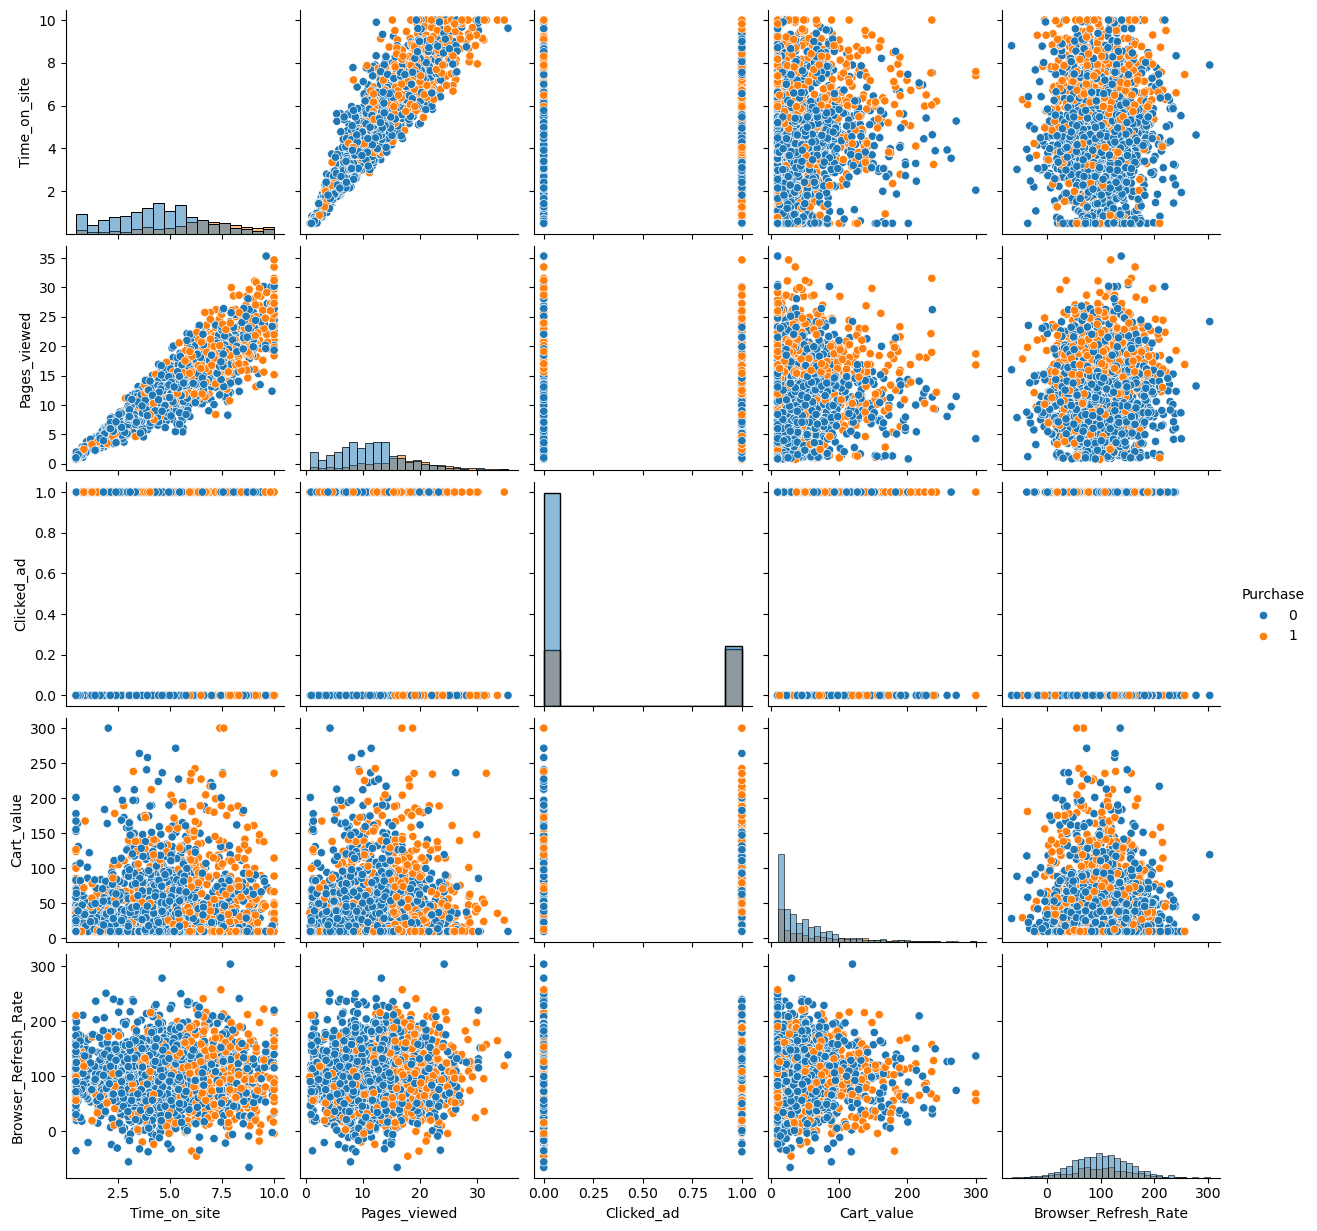

In [10]:
sns.pairplot(train_data,hue='Purchase',diag_kind='hist')

/var/folders/8l/v3f76gsx5731zkht01gyg4pc0000gn/T/ipykernel_43406/1824447773.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_data['Time_on_site'],color='red')


<Axes: xlabel='Time_on_site', ylabel='Density'>

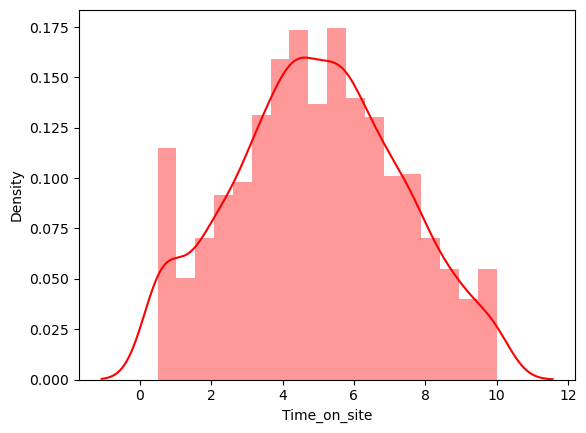

In [11]:
sns.distplot(train_data['Time_on_site'],color='red')

From this plot we can see that most people spent approx. 4-6 minutes in the websites at a time.

<Axes: xlabel='Cart_value', ylabel='Count'>

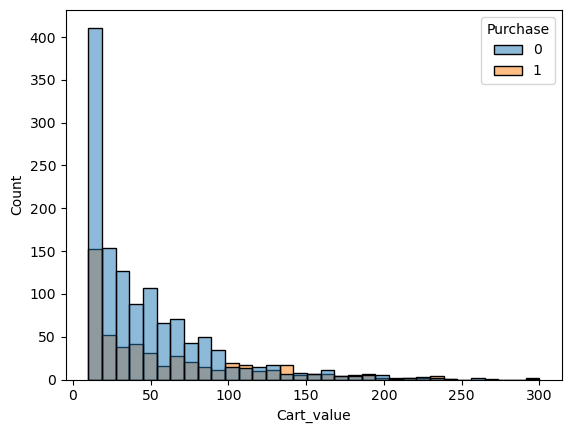

In [13]:
sns.histplot(data=train_data,x='Cart_value',hue='Purchase')

From this plot we can see that cart values of most of the people is less than 50 USD

<Axes: xlabel='Referral', ylabel='Time_on_site'>

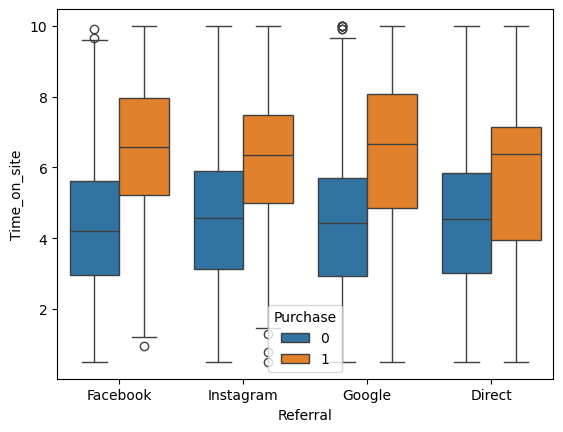

In [15]:
sns.boxplot(data=train_data,x='Referral',y='Time_on_site',hue='Purchase')

From here, we can see that those who purchase something spent a lot of time on the site and that's quite obvious

<Axes: xlabel='Pages_viewed', ylabel='Time_on_site'>

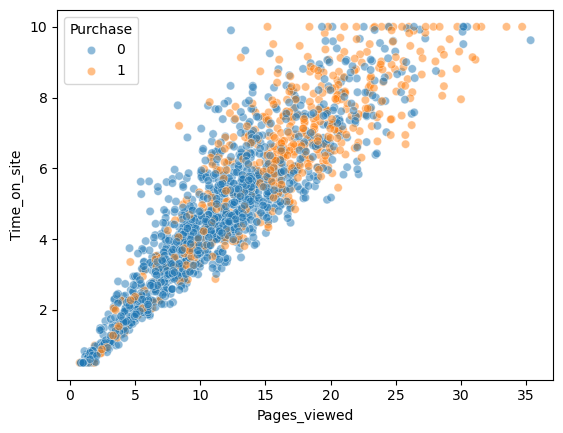

In [17]:
sns.scatterplot(data=train_data,x='Pages_viewed',y='Time_on_site',color='purple',alpha=0.5,hue='Purchase')

Those who spent more time on the site and viewed more pages ended up purchasing from that site

<Axes: xlabel='Purchase', ylabel='count'>

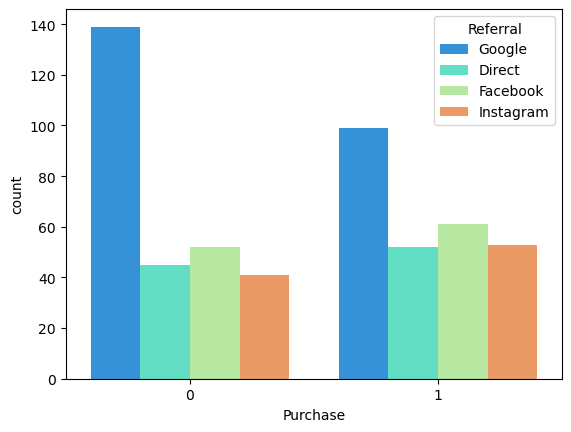

In [19]:
sns.countplot(data=train_data[train_data['Clicked_ad']==1],x='Purchase',hue='Referral',palette='rainbow')

Among the people who clicked on the Ad, less people ended up purchasing. Also we can see that people clicked mostly on google ads. This also proves google's spread.

<Axes: xlabel='Last_Ad_Seen', ylabel='count'>

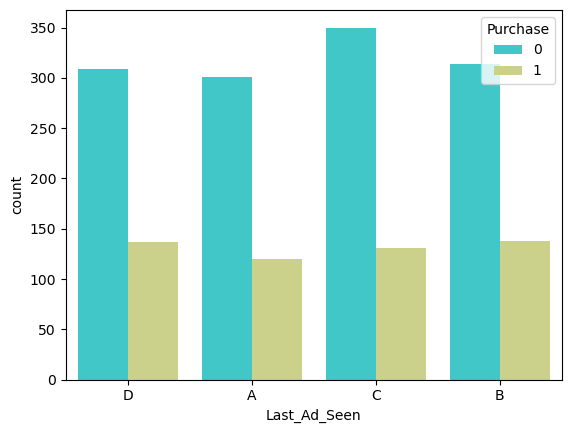

In [21]:
sns.countplot(data=train_data,hue='Purchase',x='Last_Ad_Seen',palette='rainbow')

Last Ad seen by People is mostly C

To correlate the numerical datas let's draw the heatmap

<Axes: >

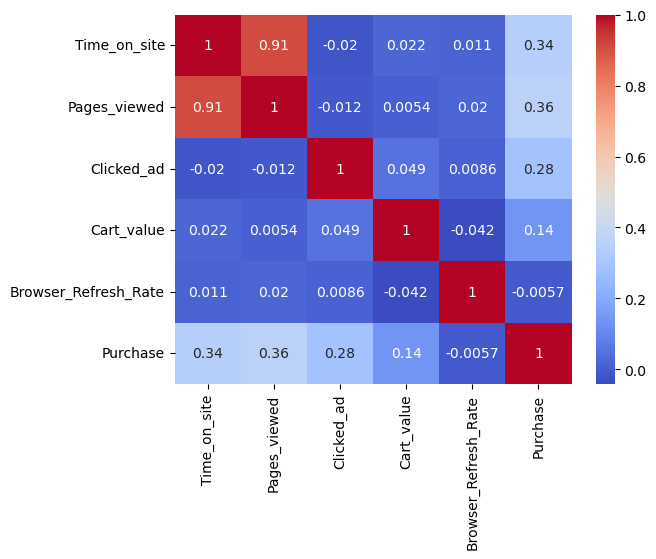

In [24]:
sns.heatmap(train_data.corr(numeric_only=True),annot=True,cmap='coolwarm')

## Data Cleaning

We can not use the text data as it is. So, we have to convert it into some numerical data. For that we are using get_dummies() function of pandas library

In [27]:
ref_dum_tr=pd.get_dummies(train_data['Referral'],drop_first=True)
ref_dum_te=pd.get_dummies(test_data['Referral'],drop_first=True)

In [28]:
ad_dum_tr=pd.get_dummies(train_data['Last_Ad_Seen'],drop_first=True)
ad_dum_te=pd.get_dummies(test_data['Last_Ad_Seen'],drop_first=True)

In [29]:
train_data=pd.concat([train_data,ref_dum_tr,ad_dum_tr],axis=1)
test_data=pd.concat([test_data,ref_dum_te,ad_dum_te],axis=1)

In [30]:
train_data.drop(['Referral','Last_Ad_Seen'],axis=1,inplace=True)
test_data.drop(['Referral','Last_Ad_Seen'],axis=1,inplace=True)

## Split the data

In [32]:
X_train=train_data.drop('Purchase',axis=1)
y_train=train_data['Purchase']
X_test=test_data.drop('Purchase',axis=1)
y_test=test_data['Purchase']

## Logistic Regression

Let's import the model from scikit-learn

In [35]:
from sklearn.linear_model import LogisticRegression

Let's call an instance of the model

In [37]:
logmod=LogisticRegression(max_iter=1000)

Let's the fit the model using training data

In [39]:
logmod.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

Let's predict output for test data

In [41]:
pred=logmod.predict(X_test)

#### Evaluation of Performance

In [43]:
from sklearn.metrics import confusion_matrix,classification_report

In [44]:
print('Confusion matrix:\n',confusion_matrix(y_test,pred),'\n',classification_report(y_test,pred))

Confusion matrix:
 [[279  35]
 [ 66  70]] 
               precision    recall  f1-score   support

           0       0.81      0.89      0.85       314
           1       0.67      0.51      0.58       136

    accuracy                           0.78       450
   macro avg       0.74      0.70      0.71       450
weighted avg       0.77      0.78      0.77       450



We are getting an accuracy of 78% and F1 score of 0.77 which is not bad

### Grid Search on Logistic Regression

In [47]:
from sklearn.model_selection import GridSearchCV

Let's define the grid parameters

In [49]:
param_grid = {
    'C' : [1,0.1,0.01,0.001],
    'max_iter'  : [1000,2500,5000],
    'penalty':['l1','l2','none']
}

In [50]:
grid=GridSearchCV(LogisticRegression(),param_grid,verbose=2)
grid.fit(X_train,y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END .....................C=1, max_iter=1000, penalty=l1; total time=   0.0s
[CV] END .....................C=1, max_iter=1000, penalty=l1; total time=   0.0s
[CV] END .....................C=1, max_iter=1000, penalty=l1; total time=   0.0s
[CV] END .....................C=1, max_iter=1000, penalty=l1; total time=   0.0s
[CV] END .....................C=1, max_iter=1000, penalty=l1; total time=   0.0s
[CV] END .....................C=1, max_iter=1000, penalty=l2; total time=   0.0s
[CV] END .....................C=1, max_iter=1000, penalty=l2; total time=   0.0s
[CV] END .....................C=1, max_iter=1000, penalty=l2; total time=   0.0s
[CV] END .....................C=1, max_iter=1000, penalty=l2; total time=   0.0s
[CV] END .....................C=1, max_iter=1000, penalty=l2; total time=   0.1s
[CV] END ...................C=1, max_iter=1000, penalty=none; total time=   0.0s
[CV] END ...................C=1, max_iter=1000,

/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
120 fits failed out of a total of 180.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solv

GridSearchCV(estimator=LogisticRegression(),
             param_grid={'C': [1, 0.1, 0.01, 0.001],
                         'max_iter': [1000, 2500, 5000],
                         'penalty': ['l1', 'l2', 'none']},
             verbose=2)

From here we get the best parameters to be: C=1 and max_iter=1000

In [52]:
pred=grid.predict(X_test)

#### Evaluation of Performance

In [54]:
print('Confusion matrix:\n',confusion_matrix(y_test,pred),'\n',classification_report(y_test,pred))

Confusion matrix:
 [[279  35]
 [ 66  70]] 
               precision    recall  f1-score   support

           0       0.81      0.89      0.85       314
           1       0.67      0.51      0.58       136

    accuracy                           0.78       450
   macro avg       0.74      0.70      0.71       450
weighted avg       0.77      0.78      0.77       450



We are getting an accuracy of 78% and F1 score of 0.77. Even after performing Grid Search we are not able to improve the performancre

### Random Forest

Let's import the model from scikit-learn

In [57]:
from sklearn.ensemble import RandomForestClassifier

Let's call an instance of the model

In [59]:
ranfor=RandomForestClassifier()

Let's the fit the model using training data

In [61]:
ranfor.fit(X_train,y_train)

RandomForestClassifier()

Let's predict output for test data

In [63]:
pred=ranfor.predict(X_test)

#### Evaluation of Performance

In [65]:
print('Confusion matrix:\n',confusion_matrix(y_test,pred),'\n',classification_report(y_test,pred))

Confusion matrix:
 [[266  48]
 [ 53  83]] 
               precision    recall  f1-score   support

           0       0.83      0.85      0.84       314
           1       0.63      0.61      0.62       136

    accuracy                           0.78       450
   macro avg       0.73      0.73      0.73       450
weighted avg       0.77      0.78      0.77       450



We are getting an accuracy of 78% and F1 score of 0.77 which is same as Logistic Regression. Let's see if we can improve our performance using Grid Search.

### Grid Search on Random Forest

Let's define the grid parameters

In [69]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

In [70]:
grid=GridSearchCV(RandomForestClassifier(),param_grid,verbose=2)
grid.fit(X_train,y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             verbose=2)

From here we get the best parameters to be: max_depth=10, min_samples_split=5 and n_estimators=200

In [72]:
pred=grid.predict(X_test)

#### Evaluation of Performance

In [74]:
print('Confusion matrix:\n',confusion_matrix(y_test,pred),'\n',classification_report(y_test,pred))

Confusion matrix:
 [[272  42]
 [ 50  86]] 
               precision    recall  f1-score   support

           0       0.84      0.87      0.86       314
           1       0.67      0.63      0.65       136

    accuracy                           0.80       450
   macro avg       0.76      0.75      0.75       450
weighted avg       0.79      0.80      0.79       450



We are getting an accuracy of 80% and F1 score of 0.79 which is better than previous ones. Grid Search worked here.

### Conclusion

Random Forest outperformed Logistic Regression in both accuracy and F1 score. Its ability to handle non-linear relationships and feature noise made it more robust. Logistic Regression is preferred when model interpretability and training speed are critical. Overall, Random Forest is more suitable for this problem due to dataset complexity.